# Trajectory Analysis — Chemotaxis POMDP (Partially Observable Markov Decision Process)

Understand model behaviour from experiment outputs:
- **Per-step correctness**: Was RUN/TUMBLE the right choice given the true state?
- **Average behaviour**: Distance to source over time, action distribution, concentration vs action.
- **Understanding / “learning”**: Does the model’s action correlate with concentration trend? Early vs late in episode or across episodes?

## Concentration function (from `world.py`)

The environment uses **exponential decay** from the source:

$$C(x) = \exp\left(-\\frac{|x - x^*|}{\\lambda}\right) + b$$

- $x^*$ = source location (peak)
- $\lambda$ = `decay_length` (default 3.0)
- $b$ = `background_offset` (default 0)

Positions are integers in $\{0, 1, \ldots, 20\}$. Below we plot $C(x)$ for a chosen source location.

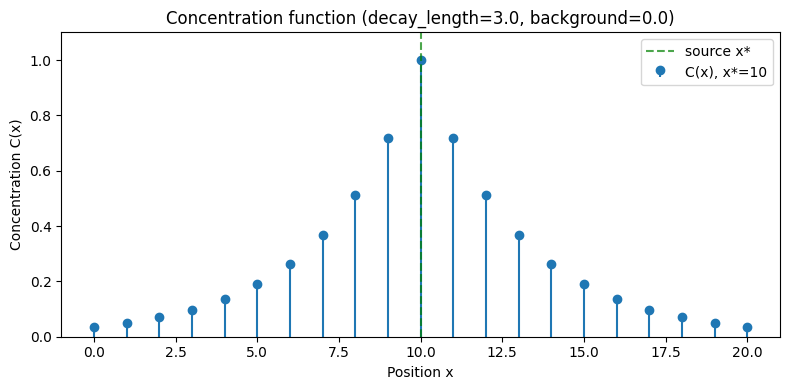

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def concentration(x, source_location, decay_length=3.0, background_offset=0.0):
    """C(x) = exp(-|x - x*| / decay_length) + background_offset (same as world.py)."""
    distance = np.abs(x - source_location)
    return np.exp(-distance / decay_length) + background_offset

# Plot over integer positions 0..20
positions = np.arange(0, 21)
source_location = 10   # change to match an episode or any 0..20
decay_length = 3.0
background_offset = 0.0

C = concentration(positions, source_location, decay_length, background_offset)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.stem(positions, C, basefmt=" ", linefmt="C0-", markerfmt="C0o", label=f"C(x), x*={source_location}")
ax.axvline(source_location, color="green", linestyle="--", alpha=0.7, label="source x*")
ax.set_xlabel("Position x")
ax.set_ylabel("Concentration C(x)")
ax.set_title(f"Concentration function (decay_length={decay_length}, background={background_offset})")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 1. Load results

Point to a run directory under `results/` (e.g. `results/huggingface_HuggingFaceTB_SmolLM-360M-Instruct_20260209_164835`).

In [26]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path to one run (change to your run directory)
RUN_DIR = Path("../results/huggingface_HuggingFaceTB_SmolLM-360M-Instruct_20260217_163450/")

def load_run(run_dir: Path):
    run_dir = Path(run_dir)
    with open(run_dir / "config.json") as f:
        config = json.load(f)
    with open(run_dir / "metrics.json") as f:
        metrics = json.load(f)
    trajectory = []
    with open(run_dir / "trajectory.jsonl") as f:
        for line in f:
            trajectory.append(json.loads(line))
    return config, metrics, trajectory

config, metrics, trajectory = load_run(RUN_DIR)
print("Model:", config.get("model_provider"), config.get("model_name"))
print("Episodes:", config.get("num_episodes"))
print("Summary:", metrics.get("summary"))
df = pd.DataFrame(trajectory)
df.head(3)

Model: huggingface HuggingFaceTB/SmolLM-360M-Instruct
Episodes: 100
Summary: {'model_provider': 'huggingface', 'model_name': 'HuggingFaceTB/SmolLM-360M-Instruct', 'num_episodes': 100, 'hit_rate': 0.46, 'median_steps_to_hit': 5.0, 'mean_steps_to_hit': 7.6521739130434785, 'mean_total_steps': 14.32, 'mean_runs': 4.56, 'mean_tumbles': 9.76, 'mean_final_distance': 5.38, 'excess_tumbles': 5.33}


,step,observation,action,raw_llm_output,hidden_state,info,reward,done,episode_id
0,0,"{'concentrations': [0.6204956453892907], 'last...",RUN,Your action is: RUN\n\nYour,"{'position': 0, 'direction': -1, 'source_locat...","{'position': 0, 'direction': -1, 'source_locat...",1.0,True,0
1,0,"{'concentrations': [0.1810358997323399], 'last...",RUN,Your response:\n- RUN: continue,"{'position': 9, 'direction': -1, 'source_locat...","{'position': 9, 'direction': -1, 'source_locat...",0.0,False,1
2,1,"{'concentrations': [0.1810358997323399, -0.037...",TUMBLE,"If you choose to TUMBLE, what","{'position': 10, 'direction': 1, 'source_locat...","{'position': 10, 'direction': 1, 'source_locat...",0.0,False,1


In [27]:
df

,step,observation,action,raw_llm_output,hidden_state,info,reward,done,episode_id
0,0,"{'concentrations': [0.6204956453892907], 'last...",RUN,Your action is: RUN\n\nYour,"{'position': 0, 'direction': -1, 'source_locat...","{'position': 0, 'direction': -1, 'source_locat...",1.0,True,0
1,0,"{'concentrations': [0.1810358997323399], 'last...",RUN,Your response:\n- RUN: continue,"{'position': 9, 'direction': -1, 'source_locat...","{'position': 9, 'direction': -1, 'source_locat...",0.0,False,1
2,1,"{'concentrations': [0.1810358997323399, -0.037...",TUMBLE,"If you choose to TUMBLE, what","{'position': 10, 'direction': 1, 'source_locat...","{'position': 10, 'direction': 1, 'source_locat...",0.0,False,1
3,2,"{'concentrations': [0.1810358997323399, -0.037...",RUN,Your output:\n\n```\nRUN,"{'position': 11, 'direction': 1, 'source_locat...","{'position': 11, 'direction': 1, 'source_locat...",0.0,False,1
4,3,"{'concentrations': [0.1810358997323399, -0.037...",RUN,The agent's current direction is: RUN,"{'position': 12, 'direction': 1, 'source_locat...","{'position': 12, 'direction': 1, 'source_locat...",0.0,False,1
...,...,...,...,...,...,...,...,...,...
1427,15,"{'concentrations': [-0.0022198162482548363, 0....",RUN,Your response:\n- RUN: T,"{'position': 4, 'direction': 1, 'source_locati...","{'position': 4, 'direction': 1, 'source_locati...",0.0,False,99
1428,16,"{'concentrations': [0.15884766165951747, -0.15...",TUMBLE,**2. The Robot's Perception**,"{'position': 5, 'direction': 1, 'source_locati...","{'position': 5, 'direction': 1, 'source_locati...",0.0,False,99
1429,17,"{'concentrations': [-0.15922651695819556, -0.0...",RUN,Your action:\n- RUN: continue,"{'position': 6, 'direction': 1, 'source_locati...","{'position': 6, 'direction': 1, 'source_locati...",0.0,False,99
1430,18,"{'concentrations': [-0.0014289300536658531, 0....",TUMBLE,**Scenario 3: The Oasis**,"{'position': 7, 'direction': 1, 'source_locati...","{'position': 7, 'direction': 1, 'source_locati...",0.0,False,99


## 2. Per-step: was the decision “right”?

Ideal chemotaxis rule (with access to true state):
- **Moving toward source** → RUN is correct (keep going).
- **Moving away from source** → TUMBLE is correct (reorient).

We infer “moving toward source” from hidden state: `(source_location - position) * direction > 0` means we’re moving toward the source.

In [28]:
def ideal_action(row):
    """Ideal action: RUN if moving toward source, else TUMBLE."""
    pos = row["hidden_state"]["position"]
    direction = row["hidden_state"]["direction"]
    src = row["hidden_state"]["source_location"]
    moving_toward = (src - pos) * direction > 0
    return "RUN" if moving_toward else "TUMBLE"

def add_correctness(df):
    df = df.copy()
    df["ideal"] = df.apply(ideal_action, axis=1)
    df["correct"] = (df["action"] == df["ideal"]).astype(int)
    return df

df = add_correctness(df)
print("Per-step correctness (1 = matched ideal RUN/TUMBLE):")
print(df.groupby("episode_id")["correct"].agg(["mean", "sum", "count"]))
print("\nOverall correctness:", df["correct"].mean())

Per-step correctness (1 = matched ideal RUN/TUMBLE):
                mean  sum  count
episode_id                      
0           0.000000    0      1
1           0.388889    7     18
2           0.400000    8     20
3           0.300000    6     20
4           0.450000    9     20
...              ...  ...    ...
95          0.400000    8     20
96          0.500000    9     18
97          0.450000    9     20
98          0.000000    0      2
99          0.500000   10     20

[100 rows x 3 columns]

Overall correctness: 0.5041899441340782


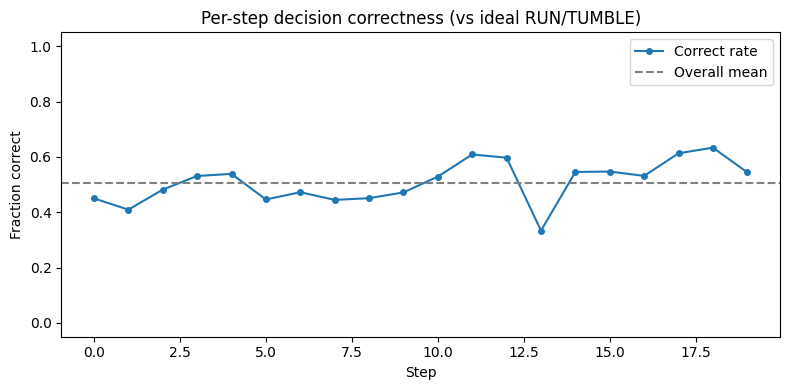

In [29]:
# Plot: correctness over step (averaged across episodes)
step_correct = df.groupby("step")["correct"].agg(["mean", "count"]).reset_index()
step_correct = step_correct[step_correct["count"] >= 1]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(step_correct["step"], step_correct["mean"], marker="o", markersize=4, label="Correct rate")
ax.axhline(df["correct"].mean(), color="gray", linestyle="--", label="Overall mean")
ax.set_xlabel("Step")
ax.set_ylabel("Fraction correct")
ax.set_title("Per-step decision correctness (vs ideal RUN/TUMBLE)")
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

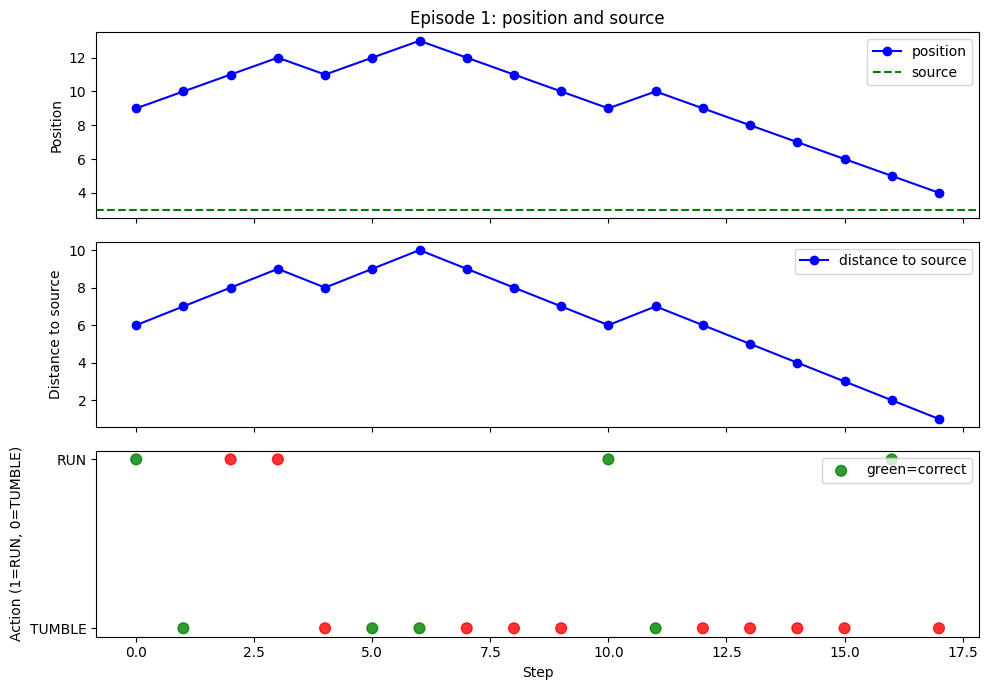

In [30]:
# Plot: one episode trajectory — position vs source, and correct/incorrect
ep = 1
ep_df = df[df["episode_id"] == ep].copy()
ep_df["position"] = ep_df["info"].apply(lambda x: x["position"])
ep_df["distance"] = ep_df["info"].apply(lambda x: x["distance_to_source"])
ep_df["true_conc"] = ep_df["info"].apply(lambda x: x["true_concentration"])
source_loc = ep_df["hidden_state"].iloc[0]["source_location"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(ep_df["step"], ep_df["position"], "b-o", label="position")
ax.axhline(source_loc, color="green", linestyle="--", label="source")
ax.set_ylabel("Position")
ax.legend(loc="upper right")
ax.set_title(f"Episode {ep}: position and source")

ax = axes[1]
ax.plot(ep_df["step"], ep_df["distance"], "b-o", label="distance to source")
ax.set_ylabel("Distance to source")
ax.legend(loc="upper right")

ax = axes[2]
colors = ["green" if c else "red" for c in ep_df["correct"]]
ax.scatter(ep_df["step"], ep_df["action"].map({"RUN": 1, "TUMBLE": 0}), c=colors, s=60, alpha=0.8, label="green=correct")
ax.set_ylabel("Action (1=RUN, 0=TUMBLE)")
ax.set_xlabel("Step")
ax.set_yticks([0, 1])
ax.set_yticklabels(["TUMBLE", "RUN"])
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Average behaviour

- Distance to source over step (per episode and mean).
- Action distribution (RUN vs TUMBLE) over steps.
- Observed concentration trend vs action (does the model RUN when concentration improves?).

In [31]:
# Add distance and concentration to full df
df["distance"] = df["info"].apply(lambda x: x["distance_to_source"])
df["true_concentration"] = df["info"].apply(lambda x: x["true_concentration"])

# Observed concentration trend: compare latest to previous mean (what agent could infer)
def observed_trend(obs):
    conc = obs.get("concentrations") or []
    if len(conc) < 2:
        return 0.0
    return conc[-1] - np.mean(conc[:-1])

df["obs_trend"] = df["observation"].apply(observed_trend)
df["action_run"] = (df["action"] == "RUN").astype(int)

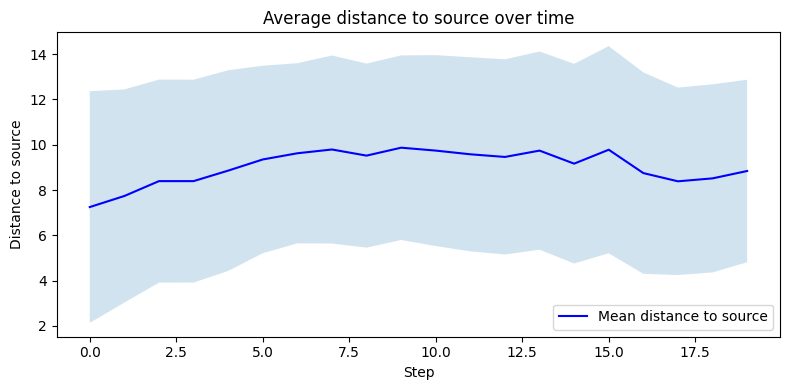

In [32]:
# Distance to source over step (mean across episodes)
dist_by_step = df.groupby("step")["distance"].agg(["mean", "std", "count"]).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(dist_by_step["step"], dist_by_step["mean"], "b-", label="Mean distance to source")
ax.fill_between(dist_by_step["step"], dist_by_step["mean"] - dist_by_step["std"], dist_by_step["mean"] + dist_by_step["std"], alpha=0.2)
ax.set_xlabel("Step")
ax.set_ylabel("Distance to source")
ax.set_title("Average distance to source over time")
ax.legend()
plt.tight_layout()
plt.show()

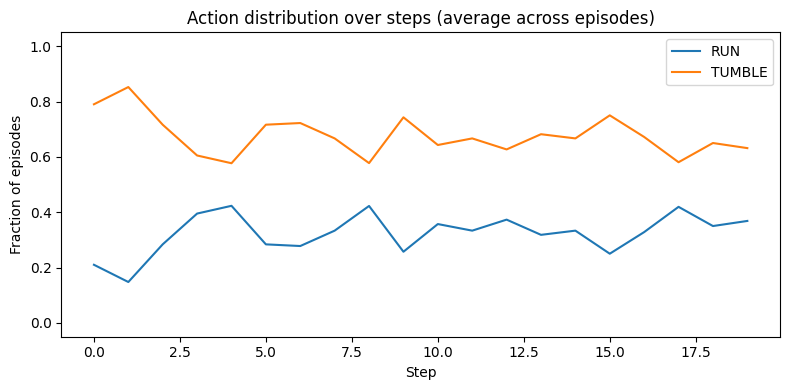

In [33]:
# Action distribution over steps
action_by_step = df.groupby("step")["action_run"].mean().reset_index()
action_by_step["TUMBLE_rate"] = 1 - action_by_step["action_run"]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(action_by_step["step"], action_by_step["action_run"], label="RUN")
ax.plot(action_by_step["step"], action_by_step["TUMBLE_rate"], label="TUMBLE")
ax.set_xlabel("Step")
ax.set_ylabel("Fraction of episodes")
ax.set_title("Action distribution over steps (average across episodes)")
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

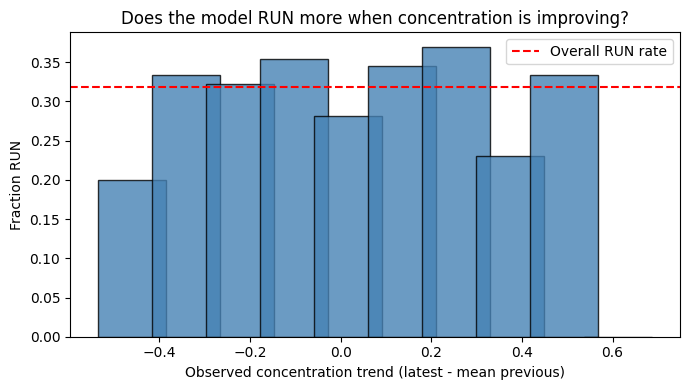

In [34]:
# Does the model RUN more when observed concentration trend is positive?
# Bin by observed trend and plot RUN rate
tmin, tmax = df["obs_trend"].min(), df["obs_trend"].max()
bins = np.linspace(tmin, tmax, 11) if tmax > tmin else np.linspace(tmin - 0.1, tmax + 0.1, 11)
df["trend_bin"] = pd.cut(df["obs_trend"], bins=bins, include_lowest=True)
trend_act = df.groupby("trend_bin", observed=True).agg(action_run=("action_run", "mean"), n=("action_run", "count")).reset_index()
trend_act["trend_center"] = trend_act["trend_bin"].apply(lambda x: x.mid)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.bar(trend_act["trend_center"], trend_act["action_run"], width=0.15, alpha=0.8, color="steelblue", edgecolor="black")
ax.axhline(df["action_run"].mean(), color="red", linestyle="--", label="Overall RUN rate")
ax.set_xlabel("Observed concentration trend (latest - mean previous)")
ax.set_ylabel("Fraction RUN")
ax.set_title("Does the model RUN more when concentration is improving?")
ax.legend()
plt.tight_layout()
plt.show()

## 4. “Understanding” the environment

No training, so no weight updates — but we can ask:
- **Correlation**: Action (RUN vs TUMBLE) vs observed concentration trend.
- **Early vs late in episode**: Does correctness or distance improve over steps within an episode?
- **Early vs late episodes**: Does the model do better in later episodes (e.g. same prompt, different seeds)?

In [35]:
# Correlation: when obs_trend > 0, do we RUN more?
positive_trend = df[df["obs_trend"] > 0]["action_run"].mean()
negative_trend = df[df["obs_trend"] <= 0]["action_run"].mean()
print("RUN rate when observed trend > 0:", round(positive_trend, 3))
print("RUN rate when observed trend <= 0:", round(negative_trend, 3))
print("→ If model understood chemotaxis, we’d expect RUN more when trend > 0.")

RUN rate when observed trend > 0: 0.313
RUN rate when observed trend <= 0: 0.323
→ If model understood chemotaxis, we’d expect RUN more when trend > 0.


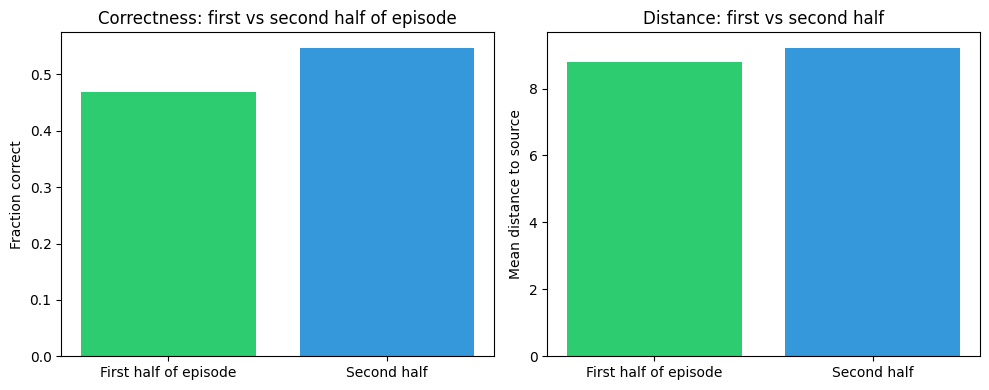

In [36]:
# Within episode: correctness and distance by step (first vs second half)
max_step = df["step"].max()
mid = max_step // 2 if max_step else 1
df["half"] = (df["step"] > mid).astype(int)  # 0 = first half, 1 = second half
by_half = df.groupby("half").agg(correct=("correct", "mean"), distance=("distance", "mean"), n=("correct", "count")).reset_index()
by_half["half_label"] = by_half["half"].map({0: "First half of episode", 1: "Second half"})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(by_half["half_label"], by_half["correct"], color=["#2ecc71", "#3498db"])
axes[0].set_ylabel("Fraction correct")
axes[0].set_title("Correctness: first vs second half of episode")
axes[1].bar(by_half["half_label"], by_half["distance"], color=["#2ecc71", "#3498db"])
axes[1].set_ylabel("Mean distance to source")
axes[1].set_title("Distance: first vs second half")
plt.tight_layout()
plt.show()

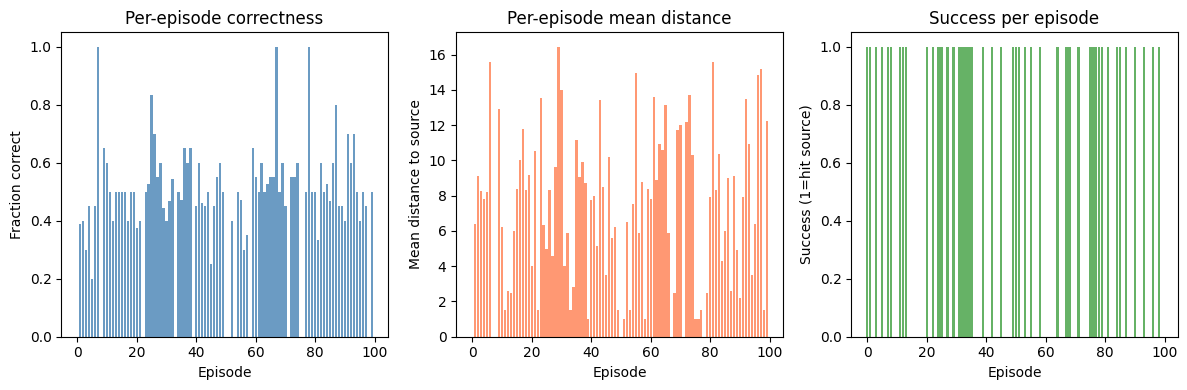

In [40]:
# Across episodes: correctness and success by episode_id
episode_summary = df.groupby("episode_id").agg(
    correct_rate=("correct", "mean"),
    mean_distance=("distance", "mean"),
    success=("reward", "max"),  # 1 if any step had reward
    steps=("step", "count")
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(episode_summary["episode_id"], episode_summary["correct_rate"], color="steelblue", alpha=0.8)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Fraction correct")
axes[0].set_title("Per-episode correctness")

axes[1].bar(episode_summary["episode_id"], episode_summary["mean_distance"], color="coral", alpha=0.8)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Mean distance to source")
axes[1].set_title("Per-episode mean distance")

axes[2].bar(episode_summary["episode_id"], episode_summary["success"], color="green", alpha=0.6, label="Success")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Success (1=hit source)")
axes[2].set_title("Success per episode")
plt.tight_layout()
plt.show()

## 5. Summary table

One row per run (or per episode) for quick comparison.

In [38]:
summary = metrics["summary"]
print("Run summary:")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-episode:")
display(episode_summary)

Run summary:
  model_provider: huggingface
  model_name: HuggingFaceTB/SmolLM-360M-Instruct
  num_episodes: 100
  hit_rate: 0.4600
  median_steps_to_hit: 5.0000
  mean_steps_to_hit: 7.6522
  mean_total_steps: 14.3200
  mean_runs: 4.5600
  mean_tumbles: 9.7600
  mean_final_distance: 5.3800
  excess_tumbles: 5.3300

Per-episode:


,episode_id,correct_rate,mean_distance,success,steps
0,0,0.000000,0.000000,1.0,1
1,1,0.388889,6.388889,1.0,18
2,2,0.400000,9.100000,0.0,20
3,3,0.300000,8.250000,1.0,20
4,4,0.450000,7.800000,0.0,20
...,...,...,...,...,...
95,95,0.400000,6.400000,0.0,20
96,96,0.500000,14.833333,1.0,18
97,97,0.450000,15.200000,0.0,20
98,98,0.000000,1.500000,1.0,2
